# Polynomial Regression

While Linear Regression assumes a straight-line relationship, real-world data is often more complex. Polynomial Regression is a form of regression analysis in which the relationship between the independent variable $x$ and the dependent variable $y$ is modeled as an $n^{th}$ degree polynomial.1. The RelationshipInstead of trying to force a straight line through a curved set of data points, Polynomial Regression "bends" the line to better fit the trend. It is still technically considered a form of Linear Regression because while the features are raised to a power, the coefficients ($\beta$) we are solving for remain linear.The mathematical representation for a polynomial of degree $n$ is:$$y = \beta_0 + \beta_1x + \beta_2x^2 + \dots + \beta_nx^n + \epsilon$$ 

Why Use It?

Non-linear Patterns: Perfect for data that grows at an increasing rate (like compound interest) or follows a wave-like pattern.Flexibility: By increasing the degree ($n$), you can model almost any relationship.

In this notebook, we explore the relationship between vehicle attributes (Odometer, Engine Power) and Price. Unlike Linear Regression, Polynomial Regression allows us to model non-linear trends, such as the rapid "initial drop" in a car's value during its first few years.

Key Objectives:

Understand how the Degree of a polynomial affects the model.
Identify Overfitting through visual "swoops".
Demonstrate the impact of Data Cleaning on model accuracy ($R^2$).

## Importing Libraries

In [92]:
try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
    from sklearn.metrics import r2_score
    from scipy import stats
    
    print('Importing successful')

except ImportError as e:
    print(f"Import failed: {e}")

Importing successful


## Import Sample Data

In [93]:
df = pd.read_csv('cars_data.csv')
print('Data importet succesfully')

Data importet succesfully


In [94]:
df.head(3)

,manufacturer,model,year,engine_power,fuel_type,transmission,odometr,price,region,description,price_category
0,Chevrolet,Nexia 3,2022.00,1.50,Benzin,Avtomat,8500,12500.00,Tashkent,"2022 yil,\n \n ...",high
1,Chevrolet,Spark,2017.00,1.30,Gaz-benzin,Mexanika,300000,6500.00,Khorezm,"2017 yil,\n \n ...",low
2,Chevrolet,Gentra,2023.00,1.60,Benzin,Avtomat,23000,15800.00,Andijan,"2023 yil,\n \n ...",high


In [95]:
df.dtypes

manufacturer       object
model              object
year              float64
engine_power      float64
fuel_type          object
transmission       object
odometr             int64
price             float64
region             object
description        object
price_category     object
dtype: object

## Extract dependent and independent variable and clean from missing values

In [96]:
df_clean = df.dropna(subset=['odometr', 'price', 'engine_power'])

df_clean = df_clean[(df_clean['price'] > 0) & (df_clean['odometr'] > 0)]

x1 = df_clean['odometr']
y1 = df_clean['price']


In [97]:
x1.head(3)

0      8500
1    300000
2     23000
Name: odometr, dtype: int64

In [98]:
y1.head(3)

0   12500.00
1    6500.00
2   15800.00
Name: price, dtype: float64

## Check shape of data

In [99]:
pd.options.display.float_format = '{:.2f}'.format
x1.describe()

count      3647.00
mean     136553.69
std      178229.22
min          10.00
25%       30000.00
50%       92000.00
75%      195000.00
max     4011000.00
Name: odometr, dtype: float64

In [100]:
y1.describe()

count     3647.00
mean     10175.85
std       8042.68
min        434.00
25%       6000.00
50%       9000.00
75%      12614.50
max     199900.00
Name: price, dtype: float64

## Scatter Plot of the variables to see if there is a linear Relationship

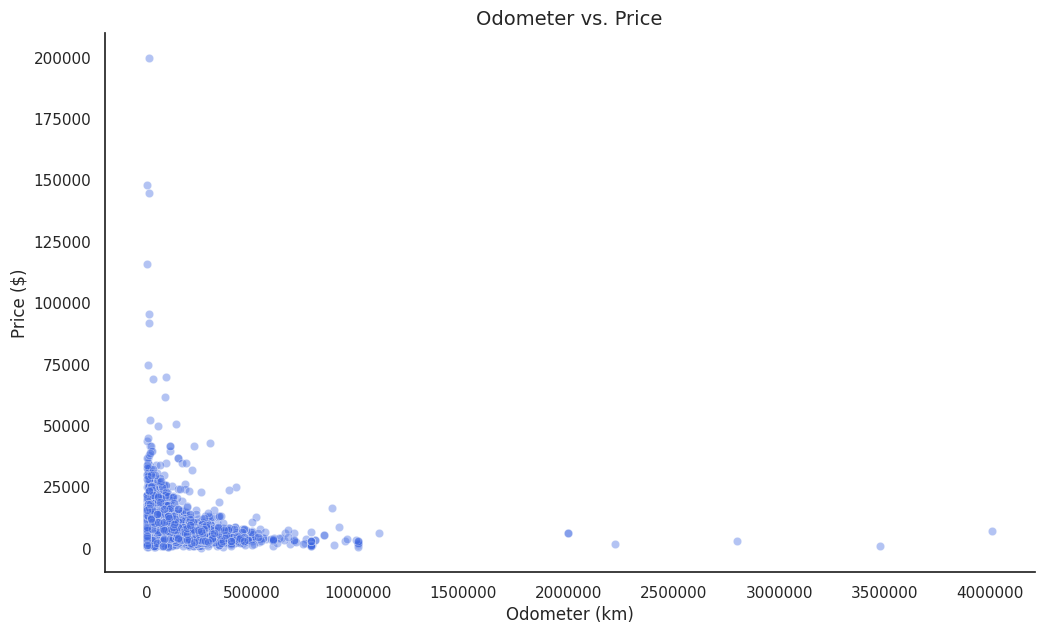

In [101]:
sns.set_style("white") 
plt.figure(figsize=(12, 7))
sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')
plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price', fontsize=14)
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
sns.despine()
plt.show()

## Setup Polynomial Regression

In [102]:
poly = np.poly1d(np.polyfit(x1, y1, 2))

## Plot the graph again with our Polynomial Function

To visualize a polynomial, we don't just plot the original data points. Instead, we use np.linspace to create 1,000 evenly spaced points across the X-axis. This ensures the resulting line is a smooth, continuous curve rather than a jagged "zig-zag" between unsorted data points.

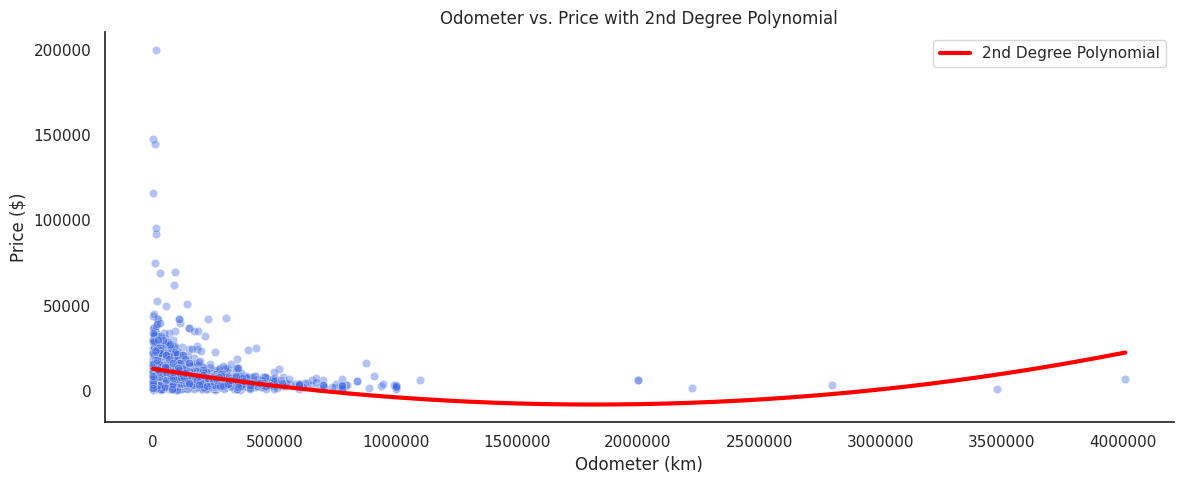

In [103]:
sns.set_style("white")
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')

x_plot = np.linspace(x1.min(), x1.max(), 1000)
y_plot = poly(x_plot)

plt.plot(x_plot, y_plot, color='red', linewidth=3, label='2nd Degree Polynomial')

plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price with 2nd Degree Polynomial')
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Increase Polynomial Degress to 4 and plot again

In [104]:
poly = np.poly1d(np.polyfit(x1, y1, 4))

## Plot the graph again with our 4th degree Polynomial Function

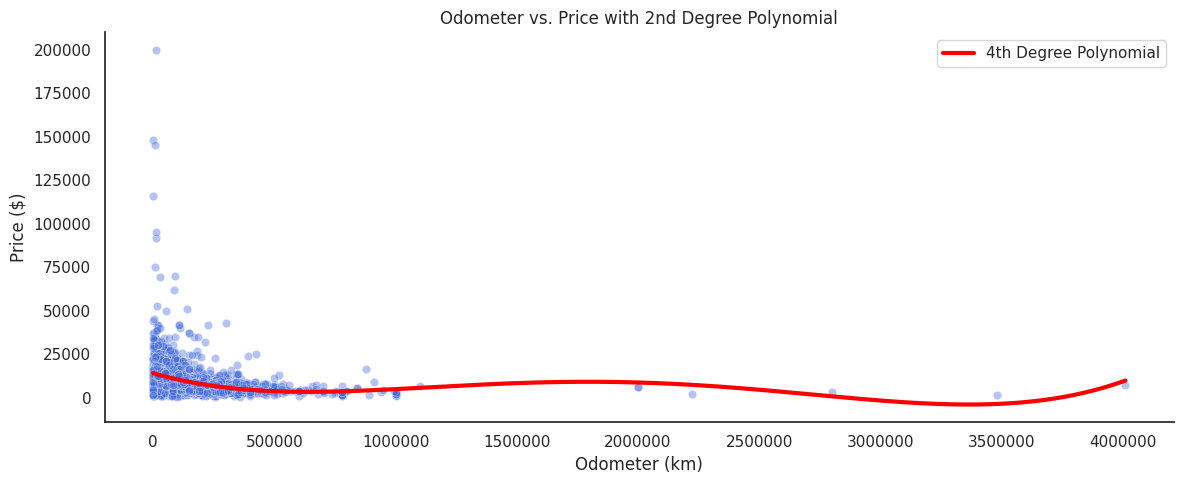

In [105]:
sns.set_style("white")
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')

x_plot = np.linspace(x1.min(), x1.max(), 1000)
y_plot = poly(x_plot)

plt.plot(x_plot, y_plot, color='red', linewidth=3, label='4th Degree Polynomial')

plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price with 2nd Degree Polynomial')
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Check different values of Degree and Check their R² Score

In [106]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
results = []

for deg in degrees:
    coef = np.polyfit(x1, y1, deg)
    poly_func = np.poly1d(coef)
    
    y_pred = poly_func(x1)
    r2 = r2_score(y1, y_pred)
    
    results.append({"Degree": deg, "R2_Score": round(r2, 4)})

df_results = pd.DataFrame(results)
print(df_results)

   Degree  R2_Score
0       1      0.08
1       2      0.12
2       3      0.13
3       4      0.14
4       5      0.14
5       6      0.14
6       7      0.14
7       8      0.14
8       9      0.14
9      10      0.14


## Remove Outliers to see which effect it has on the Polynomial Regression

The Critical Role of Data Cleaning is to improve our model from $R^2 = 0.14$. 
We will apply a strict outlier filter:

Odometer: 2 Standard Deviation (focusing on the "average" market).
Price: 3 Standard Deviations (removing extreme luxury or error-priced cars).

Removing these "leverage points" allows the polynomial to focus on the high-density area of the market, preventing the curve from being pulled away by 4-million-km outliers.

In [107]:
mean_odo = df_clean['odometr'].mean()
std_odo = df_clean['odometr'].std()

mean_price = df_clean['price'].mean()
std_price = df_clean['price'].std()


df_no_outliers = df_clean[df_clean['odometr'] < (mean_odo + 2 * std_odo)]
df_no_outliers = df_no_outliers[df_no_outliers['price'] < (mean_price + 3 * std_price)]

x1 = df_no_outliers['odometr']
y1 = df_no_outliers['price']

## Plot without Outliers

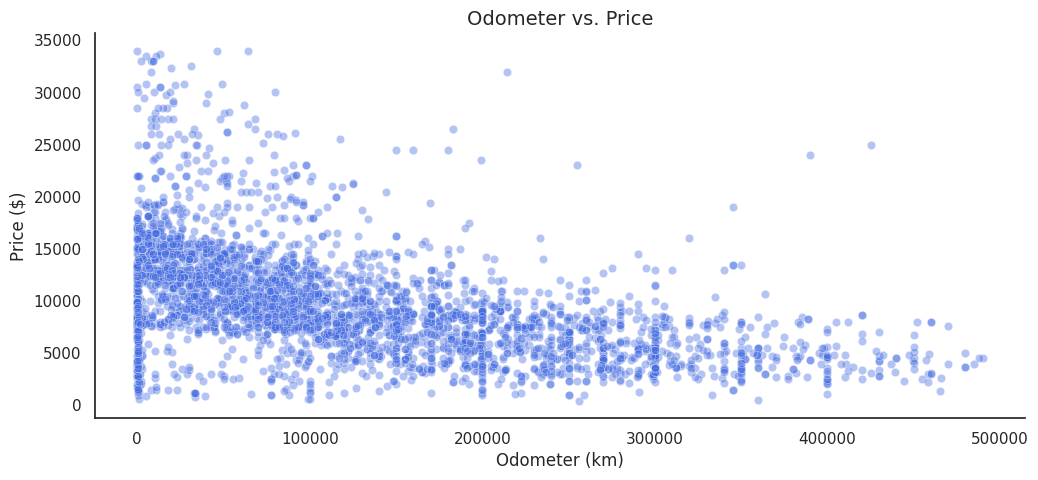

In [108]:
sns.set_style("white") 
plt.figure(figsize=(12, 5))
sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')
plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price', fontsize=14)
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
sns.despine()
plt.show()

## Setup Polynomial Regression with new Outlier free data

In [109]:
poly = np.poly1d(np.polyfit(x1, y1, 4))

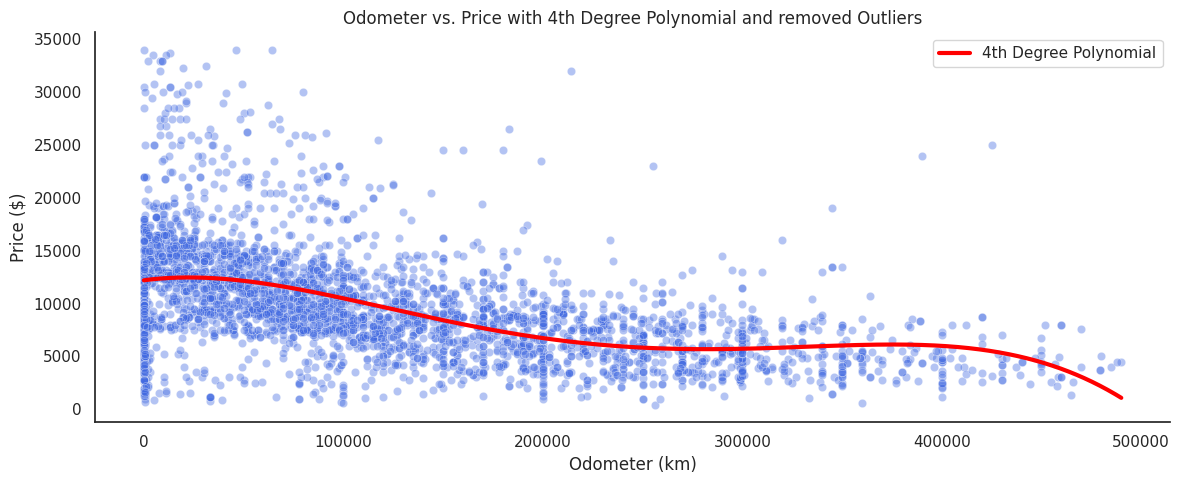

In [110]:
sns.set_style("white")
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')

x_plot = np.linspace(x1.min(), x1.max(), 1000)
y_plot = poly(x_plot)

plt.plot(x_plot, y_plot, color='red', linewidth=3, label='4th Degree Polynomial')

plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price with 4th Degree Polynomial and removed Outliers')
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Check R² with the different Values of Degree

In [111]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
results = []

for deg in degrees:
    coef = np.polyfit(x1, y1, deg)
    poly_func = np.poly1d(coef)
    y_pred = poly_func(x1)
    r2 = r2_score(y1, y_pred)
    results.append({"Degree": deg, "R2_Score": round(r2, 4)})

df_results = pd.DataFrame(results)
print(df_results)

    Degree  R2_Score
0        1      0.23
1        2      0.24
2        3      0.24
3        4      0.25
4        5      0.26
5        6      0.27
6        7      0.28
7        8      0.28
8        9      0.29
9       10      0.29
10      15      0.30


## Plot with a Polynomial Degree of 9

Model Complexity vs. Accuracy ($R^2$):

We iterate through different polynomial degrees to find the "Sweet Spot".
Low Degree (1-2): Underfits and misses the curve of depreciation.
High Degree (9-15): Overfits and the model "memorizes" noise rather than trends.

The Key to a very good fit for the Model is to clean the Data and find the "Sweet Spot" by iterating through different Degrees to prevent the Overfitting and get the best results for the Polynomial Regression Problem. In real world it will be a trade off.

In [112]:
poly = np.poly1d(np.polyfit(x1, y1, 9))

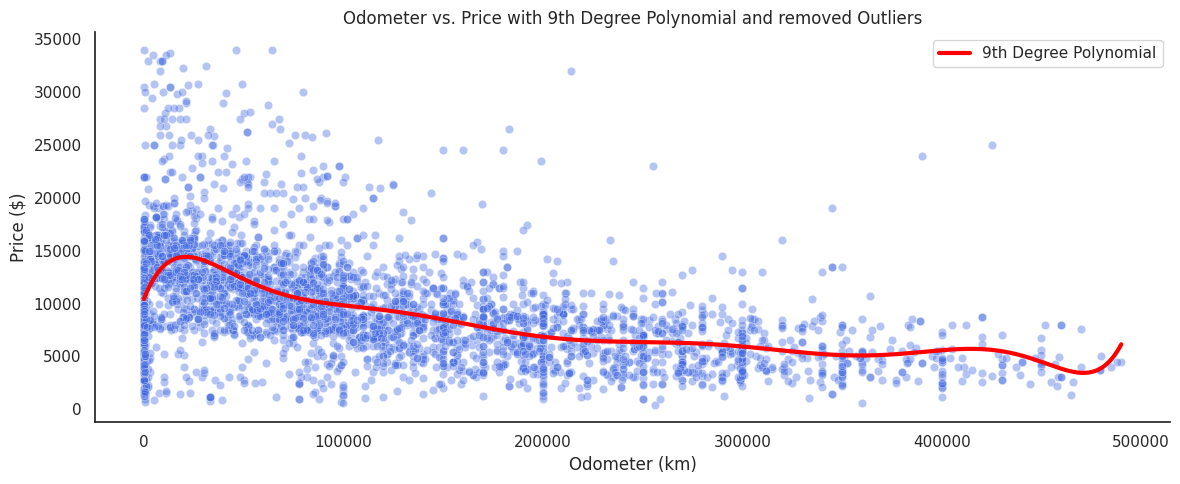

In [113]:
sns.set_style("white")
plt.figure(figsize=(12, 5))

sns.scatterplot(x=x1, y=y1, alpha=0.4, color='royalblue', edgecolor='w')

x_plot = np.linspace(x1.min(), x1.max(), 1000)
y_plot = poly(x_plot)

plt.plot(x_plot, y_plot, color='red', linewidth=3, label='9th Degree Polynomial')

plt.ticklabel_format(style='plain', axis='both')
plt.title('Odometer vs. Price with 9th Degree Polynomial and removed Outliers')
plt.xlabel('Odometer (km)')
plt.ylabel('Price ($)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## Take another Variable Engine Power to see how it Explains the price 

/tmp/ipykernel_21388/2162051493.py:11: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x_eng, y_price, deg)


R2 Scores for Engine Power vs. Price:
   Degree  R2_Score
0      15      0.30


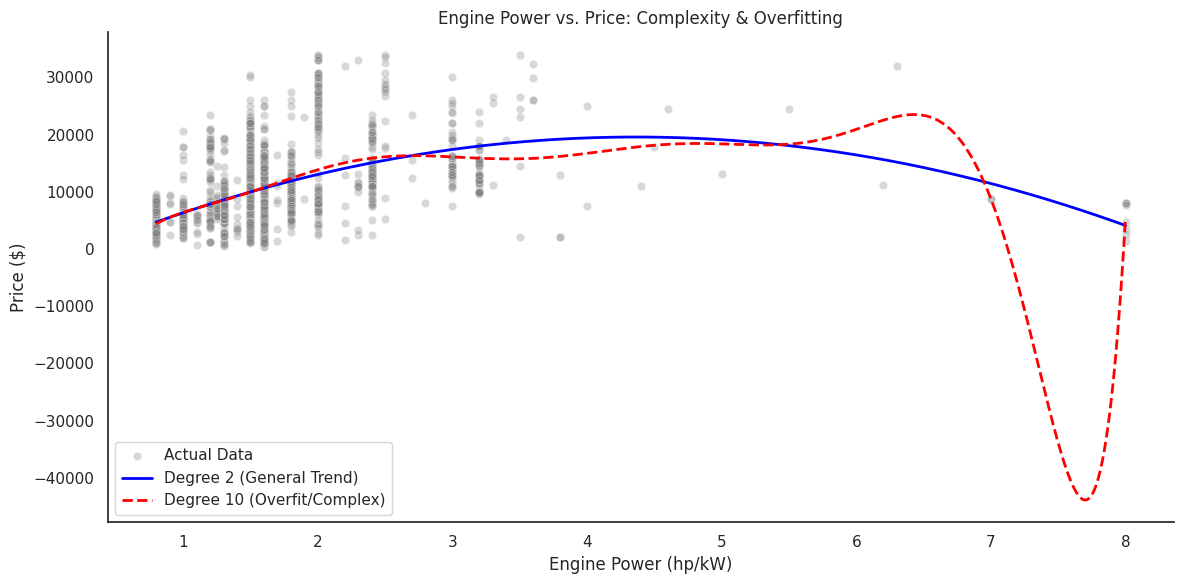

In [114]:
df_engine = df_no_outliers.dropna(subset=['engine_power']).copy()
df_engine = df_engine[df_engine['engine_power'] > 0]

x_eng = df_engine['engine_power']
y_price = df_engine['price']

degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15]
results = []

for deg in degrees:
    coef = np.polyfit(x_eng, y_price, deg)
    poly_func = np.poly1d(coef)
    y_pred = poly_func(x_eng)
    r2 = round(r2_score(y_price, y_pred), 10)

results.append({"Degree": deg, "R2_Score": r2})

df_results = pd.DataFrame(results)
print("R2 Scores for Engine Power vs. Price:")
print(df_results)

plt.figure(figsize=(12, 6))
sns.set_style("white")

sns.scatterplot(x=x_eng, y=y_price, alpha=0.3, color='grey', label='Actual Data')

x_plot = np.linspace(x_eng.min(), x_eng.max(), 1000)

p2 = np.poly1d(np.polyfit(x_eng, y_price, 2))
plt.plot(x_plot, p2(x_plot), color='blue', linewidth=2, label='Degree 2 (General Trend)')

p15 = np.poly1d(np.polyfit(x_eng, y_price, 10))
plt.plot(x_plot, p15(x_plot), color='red', linewidth=2, linestyle='--', label='Degree 10 (Overfit/Complex)')

plt.ticklabel_format(style='plain', axis='both')
plt.title('Engine Power vs. Price: Complexity & Overfitting')
plt.xlabel('Engine Power (hp/kW)')
plt.ylabel('Price ($)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

Conclusion: 
The Limits of Single-Variable Models as seen in the Engine Power vs. Price plot, a 10th-degree polynomial produces a massive "swoop" into negative values. This is a classic visual proof of Overfitting. Even with high-degree polynomials, our $R^2$ remains capped around 0.29. This proves that no single variable (Odometer or Engine Power) can fully explain car prices. 

Next Step: We must move to Multivariate Regression to combine these features into a single, more powerful predictive model.